<a href="https://colab.research.google.com/github/monish0705/ml_practice/blob/main/decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision trees are versatile machine learning algorithms that can perform both
classification and regression tasks, and even multioutput tasks. They are
powerful algorithms, capable of fitting complex datasets. For example, in

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

You can visualize the trained decision tree by first using the
export_graphviz() function to output a graph definition file called
iris_tree.dot

In [ ]:
from sklearn.tree import export_graphviz
export_graphviz(
tree_clf,
out_file="iris_tree.dot",
feature_names=["petal length (cm)", "petal width (cm)"],
class_names=iris.target_names,
rounded=True,
filled=True
)

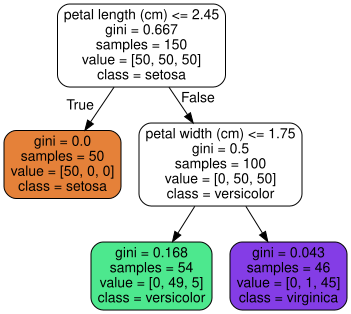

In [ ]:
from graphviz import Source
Source.from_file("iris_tree.dot")

Making Predictions

Let’s see how the tree represented in Figure 6-1 makes predictions. Suppose you
find an iris flower and you want to classify it based on its petals. You start at the
root node (depth 0, at the top): this node asks whether the flower’s petal length is
smaller than 2.45 cm. If it is, then you move down to the root’s left child node
(depth 1, left). In this case, it is a leaf node (i.e., it does not have any child
nodes), so it does not ask any questions: simply look at the predicted class for
that node, and the decision tree predicts that your flower is an Iris setosa
(class=setosa).
Now suppose you find another flower, and this time the petal length is greater
than 2.45 cm. You again start at the root but now move down to its right child
node (depth 1, right). This is not a leaf node, it’s a split node, so it asks another
question: is the petal width smaller than 1.75 cm? If it is, then your flower is
most likely an Iris versicolor (depth 2, left). If not, it is likely an Iris virginica
(depth 2, right). It’s really that simp

Gini Impurity is a metric used in decision tree algorithms to measure the likelihood of a randomly selected data point being misclassified if it were assigned a class label based on the distribution of classes within a node.

Scikit-Learn uses the CART algorithm, which produces only binary trees, meaning trees where
split nodes always have exactly two children (i.e., questions only have yes/no answers).
However, other algorithms, such as ID3, can produce decision trees with nodes that have more
than two children.


**MODEL INTERPRETATION: WHITE BOX VERSUS BLACK
BOX**

Decision trees are intuitive, and their decisions are easy to interpret. Such
models are often called white box models. In contrast, as you will see,
random forests and neural networks are generally considered black box
models. They make great predictions, and you can easily check the
calculations that they performed to make these predictions; nevertheless, it is
usually hard to explain in simple terms why the predictions were made. For
example, if a neural network says that a particular person appears in a
picture, it is hard to know what contributed to this prediction: Did the model
recognize that person’s eyes? Their mouth? Their nose? Their shoes? Or
even the couch that they were sitting on? Conversely, decision trees provide
nice, simple classification rules that can even be applied manually if need be
(e.g., for flower classification). The field of interpretable ML aims at
creating ML systems that can explain their decisions in a way humans can
understand. This is important in many domains—for example, to ensure the
system does not make unfair decisions.

In [ ]:
tree_clf.predict_proba([[5, 1.5]]).round(3)
tree_clf.predict([[5, 1.5]])

array([1])